# Tarea 01 - Modelos Lineales

## Integrantes

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodriguez Teodores Armando
* Velasco Martell Dayra

## Instrucciones

## Práctica

![img3](Imgs/T01_Inst3.png)

# Librerías

In [1]:
#General
import pandas as pd
import numpy as np
import re #RegEx

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Valores atipicos
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.mcd import MCD

In [2]:
from pandas.api.types import CategoricalDtype

In [3]:
#Codificadores
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métodos Lineales
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, LogisticRegression

#Escaladores
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

#Busqueda de hiper-parametros, train test y CV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split

#Performance
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, make_scorer, roc_auc_score
#from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#Valores para el CV
from scipy.stats import uniform

# Funciones

In [5]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [6]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#00a77d", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color, values: bool = False):
        corr_matrix = self.df[self.num_vars].corr()

        if values:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color,
                text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
                texttemplate="%{text}",                # mostrar texto en cada celda
                textfont={"size":10, "color":"black"}  # estilo de fuente
                ))
        else:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color
                ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [7]:
def detect_outliers_iforest(df, n_estimators=100, contamination=0.01, random_state=1989):
    model = IForest(n_estimators=n_estimators, contamination=contamination, random_state=random_state)
    model.fit(df.values)
    preds = model.predict(df.values)
    return df[preds == 1]

# Práctica 01 - Precio de un diamante 

Modelos lineales para la predicción del valor de un diamante de acuerdo a sus atributos.

## Carga de Datos

In [8]:
diamonds = pd.read_csv(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-II/Datasets/diamonds.csv')

In [9]:
diamonds.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


In [10]:
num_cols = diamonds.select_dtypes(['float','int']).columns

In [11]:
cat_cols = diamonds.select_dtypes(['object']).columns

In [12]:
diamonds.shape

(53940, 10)

In [13]:
clean_diamonds = diamonds.copy()

## Valores Ausentes

In [14]:
is_na_df(diamonds)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,539400,0.0,1.0


## Estadísticos

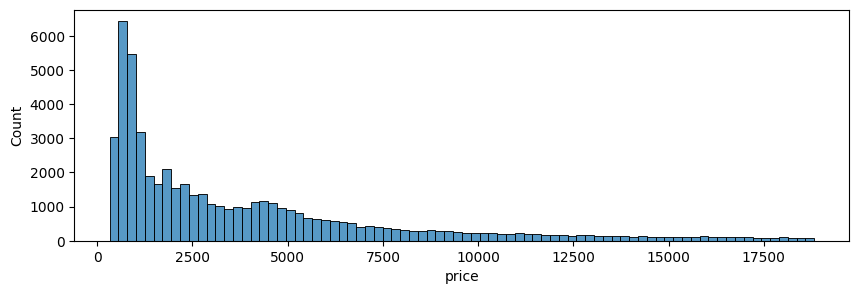

In [15]:
plt.figure(figsize=(10,3))
sns.histplot(diamonds['price'])
plt.show()

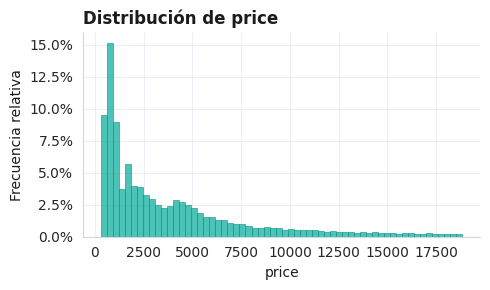

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# ---- Colores (ajusta si usas otro tono en tu deck) ----
BAR_COLOR   = "#0FAF9E"   # turquesa del tema
EDGE_COLOR  = "#0B8F82"   # borde sutil para cada barra
TEXT_COLOR  = "#1B1B1B"   # texto en gris casi negro

# ---- Estilo ----
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#D0D7DE",
    "grid.color":       "#EBEFF3",
    "grid.linestyle":   "-",
})

# ---- Plot ----
plt.figure(figsize=(5,3))
ax = sns.histplot(
    data=diamonds,
    x="price",
    bins=60,
    stat="probability",        # frecuencia relativa
    color=BAR_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.4
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("price", color=TEXT_COLOR)
ax.set_ylabel("Frecuencia relativa", color=TEXT_COLOR)
ax.set_title("Distribución de price", loc="left", color=TEXT_COLOR, weight="semibold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# ---- Guardar como PNG (fondo blanco) ----
plt.savefig("hist_price.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [17]:
analisis_diamonds = analyze(diamonds, num_cols, cat_cols)

In [18]:
analisis_diamonds.plot_num()

In [19]:
analisis_diamonds.plot_cat()

## Descripción del dataset

**Atributos de calidad** usados en gemología y explican buena parte del precio de un diamante.

* **cut (corte)**
  Calidad del tallado (proporciones, simetría y pulido). Escala típica, de mejor a peor:
  **Ideal/Excellent** → *Very Good* → *Good* → *Fair* → *Poor*.
  Un mejor corte maximiza el brillo y suele aumentar el precio (a igualdad de carat, color y claridad).

* **color**
  Grado de incoloro en diamantes blancos. Escala **D–Z** (GIA), donde **D** es totalmente incoloro (mejor) y conforme avanza hacia **Z** hay más tono amarillento/marrón (peor). En muchos datasets se restringe a **D–J**. Mejor color ⇒ mayor precio.

* **clarity (claridad)**
  Cantidad y visibilidad de inclusiones/imperfecciones. Escala típica (mejor → peor):
  **FL/IF** (Flawless/Internally Flawless) → **VVS1, VVS2** → **VS1, VS2** → **SI1, SI2** → **I1, I2, I3**.
  Más limpia ⇒ mayor precio.

* **carat**: peso del diamante (principal determinante de precio; relación no lineal).

* **depth, table**: proporciones geométricas (% de altura total y % de mesa).

* **x, y, z**: dimensiones en mm (largo, ancho, alto).

* **price**: precio en USD (objetivo).

In [20]:
# peor → mejor (J como menor, D como mayor)
color_order = ['J','I','H','G','F','E','D'] 
dtype = CategoricalDtype(categories=color_order, ordered=True)
clean_diamonds['color_cat'] = clean_diamonds['color'].astype(dtype)

In [21]:
# corte del diamante (peor → mejor)
cut_order = ['Fair','Good','Very Good','Premium','Ideal'] 
dtype = CategoricalDtype(categories=cut_order, ordered=True)
clean_diamonds['cut_cat'] = clean_diamonds['cut'].astype(dtype)

In [22]:
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
dtype = CategoricalDtype(categories=clarity_order, ordered=True)
clean_diamonds['clarity_cat'] = clean_diamonds['clarity'].astype(dtype)

## Descriptivos

In [23]:
percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

In [24]:
diamonds.describe(percentiles=percentiles).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
carat,53940.0,0.797940,0.474011,0.2,0.24,0.30,0.40,0.70,1.04,1.70,2.18,5.01
depth,53940.0,61.749405,1.432621,43.0,57.90,59.30,61.00,61.80,62.50,63.80,65.60,79.00
table,53940.0,57.457184,2.234491,43.0,53.00,54.00,56.00,57.00,59.00,61.00,64.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,429.00,544.00,950.00,2401.00,5324.25,13107.10,17378.22,18823.00
x,53940.0,5.731157,1.121761,0.0,4.02,4.29,4.71,5.70,6.54,7.66,8.36,10.74
y,53940.0,5.734526,1.142135,0.0,4.04,4.30,4.72,5.71,6.54,7.65,8.34,58.90
z,53940.0,3.538734,0.705699,0.0,2.48,2.65,2.91,3.53,4.04,4.73,5.15,31.80


## Análisis Descriptivo

* No se observan valores ausentes en el dataset.

* Las variables categóricas son variables ordinales ya que en realidad los valores si representan una peor o mejor calificación del atributo del diamante del que se esté hablando. Por otra parte, la mayoría de las categorías tienen una proporción entre un rango del 15% al 20% por lo que no están altamente desproporcionadas, a excepción del valor *Ideal* en la variable **cut** con una proporción cerca del 40% de los registros.

* Las variables continuas como x, y, z tienen pocos valores atípicos a diferencia del resto. Por ejemplo, se puede observar de los descriptivos y gráficos de caja que los valores extremos del peso y el precio del diamante se alejan más de la media y la mediana, hablándonos de una mayor dispersión de los valores.

Vamos aplicar el método de Insolation Forest para detectar estos valores atípicos y así poderlos remover del dataset.

## Valores Atípicos

In [25]:
diamonds_outliers = detect_outliers_iforest(diamonds[num_cols])

In [26]:
diamonds_outliers

,carat,depth,table,price,x,y,z
2,0.23,56.9,65.0,327,4.05,4.07,2.31
14,0.20,60.2,62.0,345,3.79,3.75,2.27
54,0.22,59.3,62.0,404,3.91,3.88,2.31
13002,2.14,69.4,57.0,5405,7.74,7.70,5.36
13029,0.23,58.1,63.0,600,4.08,4.04,2.36
...,...,...,...,...,...,...,...
37598,0.23,59.0,63.0,485,3.98,4.05,2.37
38278,0.21,59.1,62.0,386,3.89,3.86,2.29
40614,0.23,56.3,62.0,498,4.10,4.11,2.31
52860,0.50,79.0,73.0,2579,5.21,5.18,4.09


In [27]:
ratio = diamonds_outliers.shape[0]/diamonds.shape[0]
print(f'{ratio:.2%}')

1.00%


Encontramos 540 valores atípicos los cuales representan el 1% de nuestro dataset crudo, vamos a eliminar dichos registros.

In [28]:
clean_diamonds.drop(index=diamonds_outliers.index, inplace=True)

In [29]:
clean_diamonds.drop(columns=['cut','color','clarity'], inplace=True)

## Codificación de Variables Ordinales

In [30]:
y = clean_diamonds.loc[:, "price"]
X = clean_diamonds.loc[:, [x for x in clean_diamonds.columns if x != 'price']]

In [31]:
print(X.columns.tolist())

['carat', 'depth', 'table', 'x', 'y', 'z', 'color_cat', 'cut_cat', 'clarity_cat']


In [32]:
num_cols  = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols  = ['cut_cat', 'color_cat', 'clarity_cat'] 

#X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Codificación de variables ordinales

# Corte del diamante
X.loc[:, 'cut_cat_id'] = np.ravel(OrdinalEncoder(categories=[cut_order]).fit_transform(X.loc[:, ['cut_cat']]))
display(X.loc[:, ['cut_cat', 'cut_cat_id']].drop_duplicates().sort_values(by=['cut_cat_id']).T)

# Color del diamante
X.loc[:, 'color_cat_id'] = np.ravel(OrdinalEncoder(categories=[color_order]).fit_transform(X.loc[:, ['color_cat']]))
display(X.loc[:, ['color_cat', 'color_cat_id']].drop_duplicates().sort_values(by=['color_cat_id']).T)

# Claridad del diamante
X.loc[:, 'clarity_cat_id'] = np.ravel(OrdinalEncoder(categories=[clarity_order]).fit_transform(X.loc[:, ['clarity_cat']]))
display(X.loc[:, ['clarity_cat', 'clarity_cat_id']].drop_duplicates().sort_values(by=['clarity_cat_id']).T)

X.drop(columns=['cut_cat','color_cat','clarity_cat'], inplace=True)

# Particion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1077)

X_train_original = X_train.loc[:, num_cols].copy() # variables continuas en escala origen
X_test_original = X_test.copy()

# Escalamiento de variables continuas
scaler = MinMaxScaler()
scaler.fit(X_train.loc[:, num_cols])

X_train.loc[:, num_cols] = scaler.transform(X_train.loc[:, num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test.loc[:, num_cols])

,8,4,5,1,0
cut_cat,Fair,Good,Very Good,Premium,Ideal
cut_cat_id,0.0,1.0,2.0,3.0,4.0


,4,3,7,25,12,0,28
color_cat,J,I,H,G,F,E,D
color_cat_id,0.0,1.0,2.0,3.0,4.0,5.0,6.0


,15,0,1,3,9,5,6,229
clarity_cat,I1,SI2,SI1,VS2,VS1,VVS2,VVS1,IF
clarity_cat_id,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0


In [33]:
print("num_cols", num_cols, end='\n\n')
print("X_train columns =", X_train.columns.tolist())

num_cols ['carat', 'depth', 'table', 'x', 'y', 'z']

X_train columns = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_cat_id', 'color_cat_id', 'clarity_cat_id']


## Regresión Ordinaria

In [34]:
class Regresion:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.model = None
        self.y_fitted = None
        self.y_pred = None

    #Ajustamos el modelo
    def fit_reg(self):
        self.model = LinearRegression(fit_intercept=True)
        self.model.fit(self.X_train, self.y_train)
        
        #Calculamos predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)
        return self.model

    #Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
            
        cfs = [self.model.intercept_]
        cfs.extend(list(self.model.coef_))
        coef_names = ["intercept"] + list(self.X_train.columns)

        dt = {"Vars": coef_names, "Coefs": cfs}
        df_coefs = pd.DataFrame(dt)
        
        return df_coefs

    #Validacion cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        
        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="r2"
        )
        cv_values = {
            "media": np.round(np.mean(cv_score),3),
            "mediana": np.round(np.median(cv_score),3),
            "desv. est": np.round(np.std(cv_score, ddof=1),3)
        }
        return cv_values

    #Metricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg() para calcular predicciones")
        
        r2_train = np.round(r2_score(self.y_train, self.y_fitted), 3)
        r2_test  = np.round(r2_score(self.y_test, self.y_pred), 3)

        rmse_train = np.round(root_mean_squared_error(self.y_train, self.y_fitted), 3)
        rmse_test  = np.round(root_mean_squared_error(self.y_test, self.y_pred), 3)

        mae_train = np.round(mean_absolute_error(self.y_train, self.y_fitted), 3)
        mae_test  = np.round(mean_absolute_error(self.y_test, self.y_pred), 3)

        mape_train = np.round(mean_absolute_percentage_error(self.y_train, self.y_fitted), 3)
        mape_test  = np.round(mean_absolute_percentage_error(self.y_test, self.y_pred), 3)

        perform = {
            "Metrica": [
                "R2_train", "R2_test",
                "rmse_train", "rmse_test",
                "mae_train", "mae_test",
                "mape_train", "mape_test"
            ],
            "Valor": [
                r2_train, r2_test,
                rmse_train, rmse_test,
                mae_train, mae_test,
                mape_train, mape_test
            ]
        }
        return pd.DataFrame(perform)

In [35]:
#Instanciamos el modelo
lmodel = Regresion(X_train, X_test, y_train, y_test)

In [36]:
#Entrenamos y ajustamos
lmodel.fit_reg()

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(37380, 9) (37380,) (16020, 9) (16020,)


In [38]:
#Coeficientes del modelo
lmodel.coefs()

,Vars,Coefs
0,intercept,4953.809958
1,carat,28064.653637
2,depth,-3255.166315
3,table,-1176.441489
4,x,-13143.013866
5,y,-1309.098750
6,z,-819.521784
7,cut_cat_id,112.008119
8,color_cat_id,328.789400
9,clarity_cat_id,483.192924


In [39]:
#Validación cruzada
lmodel.cross_values()

{'media': 0.914, 'mediana': 0.914, 'desv. est': 0.001}

In [40]:
#Performance 
lmodel.performance()

,Metrica,Valor
0,R2_train,0.915
1,R2_test,0.910
2,rmse_train,1117.628
3,rmse_test,1145.262
4,mae_train,759.266
5,mae_test,764.182
6,mape_train,0.418
7,mape_test,0.426


In [41]:
def unscale_coeficients(coef: pd.DataFrame, X_train_original: pd.DataFrame, continuos_cols: list):
    mins  = X_train_original[continuos_cols].min()
    rngs  = X_train_original[continuos_cols].max() - X_train_original[continuos_cols].min()
    
    df_out = coef.copy()
    df_out["Coef_OriginalScale"] = df_out["Coefs"]  # inicializa igual
    
    # pendientes de continuas
    for v in continuos_cols:
        df_out.loc[df_out["Vars"] == v, "Coef_OriginalScale"] = (
            df_out.loc[df_out["Vars"] == v, "Coefs"].values[0] / rngs[v]
        )
    
    # intercepto
    beta0p = df_out.loc[df_out["Vars"] == "intercept", "Coefs"].values[0]
    ajuste = sum(
        df_out.loc[df_out["Vars"] == v, "Coefs"].values[0] * (mins[v] / rngs[v])
        for v in num_cols
    )
    beta0 = beta0p - ajuste
    df_out.loc[df_out["Vars"] == "intercept", "Coef_OriginalScale"] = beta0
    
    df_out.set_index("Vars", inplace=True)
    return df_out

In [42]:
new_coefs = unscale_coeficients(coef=lmodel.coefs(), X_train_original=X_train_original, continuos_cols=num_cols)
display(new_coefs)

,Coefs,Coef_OriginalScale
Vars,,
intercept,4953.809958,8416.247982
carat,28064.653637,12585.046474
depth,-3255.166315,-106.377984
table,-1176.441489,-32.678930
x,-13143.013866,-1528.257426
y,-1309.098750,-22.225785
z,-819.521784,-25.771125
cut_cat_id,112.008119,112.008119
color_cat_id,328.789400,328.789400


In [43]:
y_diff = pd.concat([pd.Series(y_test.values, name='y'), pd.Series(lmodel.y_pred, name='y_predicted')], axis=1)
#y_diff['y_'] = y_diff[]-y_diff[]

In [44]:
def validacion(model, coefs: pd.DataFrame, X_test_original: pd.DataFrame, continous_cols: list):
    # predicciones con el modelo escalado
    # y_pred_scaled_domain = lmodel.predict(X_test_scaled)
    y_pred_scaled_domain = model.y_pred
    
    # predicciones con X original + coef originales
    b = coefs['Coef_OriginalScale'].to_dict()
    b0 = b['intercept']
    
    vars_cont = continous_cols
    vars_cat  = [c for c in coefs.index if c not in vars_cont and c != 'intercept']
    
    y_pred_orig_domain = (
        b0
        + X_test_original[vars_cont].mul([b[v] for v in vars_cont], axis=1).sum(1)
        + X_test_original[vars_cat].mul([b[v] for v in vars_cat], axis=1).sum(1)
    )
    
    print(np.allclose(y_pred_scaled_domain, y_pred_orig_domain, atol=1e-8))

    return y_pred_scaled_domain, y_pred_orig_domain

In [45]:
y_pred_scaled, y_pred_orig = validacion(
    model=lmodel, 
    coefs=new_coefs, 
    X_test_original=X_test_original, 
    continous_cols=num_cols
)

True


In [46]:
# Primeros 5 registros, y predicha con modelo y y predicha con fórmula por coeficientes y variables x
pd.concat([pd.Series(y_pred_scaled, name='y_pred_scaled'), pd.Series(y_pred_orig.values, name='y_pred_orig')], axis=1).head()

,y_pred_scaled,y_pred_orig
0,397.538089,397.538089
1,-911.995063,-911.995063
2,6340.932638,6340.932638
3,-310.587109,-310.587109
4,770.470466,770.470466


In [47]:
def plot_pred_vs_actual(y_true: np.array, y_hat: np.array, title="Predicción vs Observado"):
        if y_hat is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")

        #y_true = self.y_test
        #y_hat  = self.y_pred

        # rmse = mean_squared_error(y_true, y_hat, squared=False)
        rmse = root_mean_squared_error(y_true, y_hat)
        r2   = r2_score(y_true, y_hat)

        vmin = np.min([y_true.min(), y_hat.min()])
        vmax = np.max([y_true.max(), y_hat.max()])

        plt.figure(figsize=(6,6))
        plt.scatter(y_true, y_hat, alpha=0.5)
        plt.plot([vmin, vmax], [vmin, vmax], lw=2)  # diagonal y=x
        plt.title(f"{title}\nRMSE={rmse:.2f} | R²={r2:.3f}")
        plt.xlabel("y observada (test)")
        plt.ylabel("y predicha")
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.grid(True, alpha=0.3)
        plt.show()

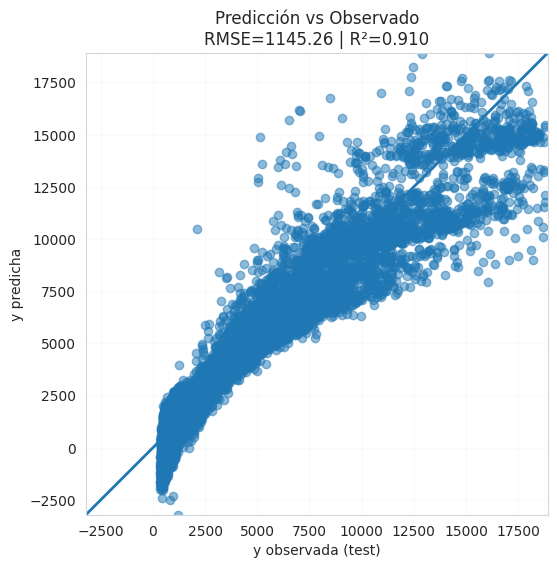

In [48]:
plot_pred_vs_actual(y_true=y_test, y_hat=lmodel.y_pred)

In [49]:
b = unscale_coeficients(coef=lmodel.coefs(), X_train_original=X_train_original, continuos_cols=num_cols)['Coef_OriginalScale'].to_dict()
b0 = b['intercept']

y_pred_orig_domain = (
        b0
        + X_test_original[num_cols].mul([b[v] for v in num_cols], axis=1).sum(1)
        + X_test_original[[x + '_id' for x in cat_cols]].mul([b[v + '_id'] for v in cat_cols], axis=1).sum(1)
    )

In [50]:
pd.DataFrame(pd.Series(b).apply(lambda x: '${0:.2f}'.format(x))).T#.to_clipboard()

,intercept,carat,depth,table,x,y,z,cut_cat_id,color_cat_id,clarity_cat_id
0,$8416.25,$12585.05,$-106.38,$-32.68,$-1528.26,$-22.23,$-25.77,$112.01,$328.79,$483.19


In [51]:
pd.concat([X_test_original, pd.Series(lmodel.y_pred, name='y_predicha', index=X_test.index)], axis=1).head()

,carat,depth,table,x,y,z,cut_cat_id,color_cat_id,clarity_cat_id,y_predicha
34913,0.34,62.5,55.0,4.51,4.48,2.81,4.0,4.0,3.0,397.538089
43993,0.30,62.2,58.0,4.22,4.33,2.66,2.0,4.0,1.0,-911.995063
18111,1.03,61.8,59.0,6.46,6.48,4.00,3.0,4.0,4.0,6340.932638
38991,0.50,62.8,60.0,5.04,5.08,3.18,2.0,1.0,2.0,-310.587109
34366,0.41,61.6,59.0,4.74,4.77,2.93,3.0,4.0,3.0,770.470466


In [52]:
# predict y sin escala 

b = unscale_coeficients(coef=lmodel.coefs(), X_train_original=X_train_original, continuos_cols=num_cols)['Coef_OriginalScale'].to_dict()
b0 = b['intercept']

suma = 0
for x in X_test.columns:
    suma += b[x] * X_test_original.loc[34913, x]

y0 = b0 + suma
print(round(y0,6))

397.538089


In [53]:
print(round(lmodel.y_pred[0], 6))

397.538089


In [54]:
# predict y con escala

b = lmodel.coefs().set_index('Vars')['Coefs'].to_dict()
b0 = b['intercept']

suma = 0
for x in X_test.columns:
    suma += b[x] * X_test.loc[34913, x]

y0 = b0 + suma
print(round(y0,6))

397.538089


### Regresión Ridge

In [55]:
class RidgeRegression:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.model = None
        self.y_fitted = None
        self.y_pred = None

    #Ajustamos el modelo
    def fit_reg(self, alpha = 1):
        self.model = Ridge(fit_intercept=True, alpha = alpha)
        self.model.fit(self.X_train, self.y_train)
        
        #Calculamos predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)
        return self.model

    #Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
            
        cfs = [self.model.intercept_]
        cfs.extend(list(self.model.coef_))
        coef_names = ["intercept"] + list(self.X_train.columns)

        dt = {"Vars": coef_names, "Coefs": cfs}
        df_coefs = pd.DataFrame(dt)
        
        return df_coefs

    #Validacion cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        
        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="r2"
        )
        cv_values = {
            "media": np.round(np.mean(cv_score),3),
            "mediana": np.round(np.median(cv_score),3),
            "desv. est": np.round(np.std(cv_score, ddof=1),3)
        }
        return cv_values

    #Metricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg() para calcular predicciones")
        
        r2_train = np.round(r2_score(self.y_train, self.y_fitted), 3)
        r2_test  = np.round(r2_score(self.y_test, self.y_pred), 3)

        rmse_train = np.round(root_mean_squared_error(self.y_train, self.y_fitted), 3)
        rmse_test  = np.round(root_mean_squared_error(self.y_test, self.y_pred), 3)

        mae_train = np.round(mean_absolute_error(self.y_train, self.y_fitted), 3)
        mae_test  = np.round(mean_absolute_error(self.y_test, self.y_pred), 3)

        mape_train = np.round(mean_absolute_percentage_error(self.y_train, self.y_fitted), 3)
        mape_test  = np.round(mean_absolute_percentage_error(self.y_test, self.y_pred), 3)

        perform = {
            "Metrica": [
                "R2_train", "R2_test",
                "rmse_train", "rmse_test",
                "mae_train", "mae_test",
                "mape_train", "mape_test"
            ],
            "Valor": [
                r2_train, r2_test,
                rmse_train, rmse_test,
                mae_train, mae_test,
                mape_train, mape_test
            ]
        }
        return pd.DataFrame(perform)
    
    #Graficamos las variables penalizadas
    def plot_features(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")

        coefs = pd.Series(self.model.coef_, index=self.X_train.columns)
        coefs_sorted = coefs.sort_values()

        plt.figure(figsize=(10, 6))
        colors = ['#de3163' if c < 0 else 'navy' for c in coefs_sorted]
        coefs_sorted.plot(kind='barh', color=colors)

        plt.title(f'Coeficientes')
        plt.xlabel('Valor del coeficiente (penalizado)')
        plt.ylabel('Variables')
        plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

**Búsqueda de hiperparámetros**

In [56]:
#Búsqueda de mejor hiperparametro alpha
ridge_cv = Ridge()

#Mejor parametro alpha
param_grid = {
    "alpha": uniform(0, 15)
}

#Búsqueda aleatoria
ridge_search = RandomizedSearchCV(
    estimator=ridge_cv,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=1989,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

#Mejores parámetros
best_ridge = ridge_search.best_estimator_
print("Mejor parámetro alpha:", ridge_search.best_params_)

best_alpha = ridge_search.best_params_["alpha"]

Mejor parámetro alpha: {'alpha': 0.17672815267167075}


**Mejor modelo**

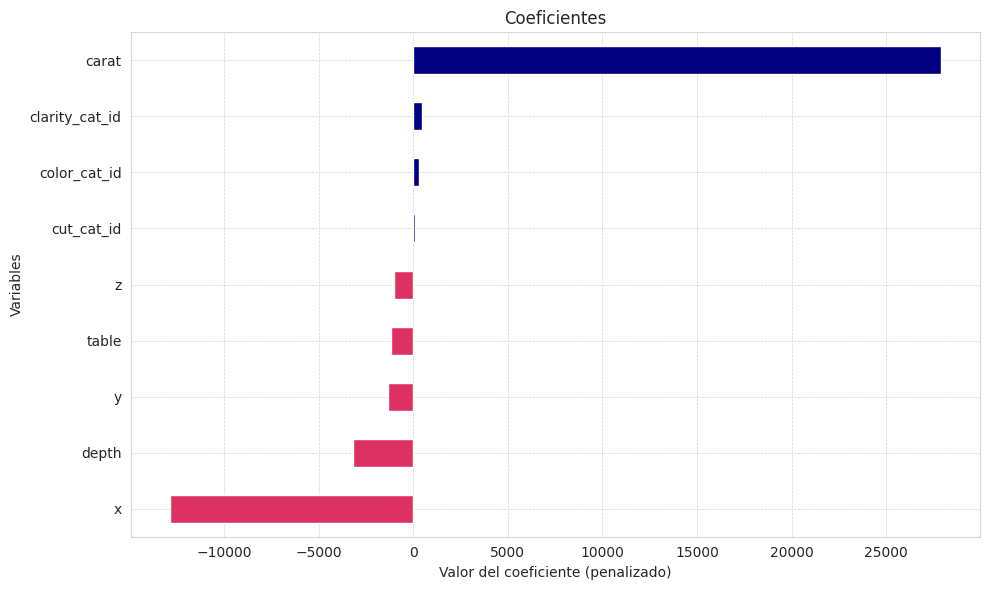

In [57]:
#Instanciamos el modelo
ridge_model = RidgeRegression(X_train, X_test, y_train, y_test)

#Entrenamos y ajustamos
ridge_model.fit_reg(alpha = best_alpha)

#Coeficientes del modelo
ridge_model.coefs()

#Validación cruzada
ridge_model.cross_values()

#Performance 
ridge_model.performance()

ridge_model.plot_features()

### Regresión LASSO

In [58]:
class LassoRegression:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.model = None
        self.y_fitted = None
        self.y_pred = None

    #Ajustamos el modelo
    def fit_reg(self, alpha = 1):
        self.model = Lasso(fit_intercept=True, alpha = alpha)
        self.model.fit(self.X_train, self.y_train)
        
        #Calculamos predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)
        return self.model

    #DataFrame con valores observados, ajustados/predichos y residuales
    def fitted_values(self, dataset="train"):
        if dataset == "train":
            df = pd.DataFrame({
                "Observed": self.y_train,
                "Fitted": self.y_fitted,
                "Residual": self.y_train - self.y_fitted
            })
        elif dataset == "test":
            df = pd.DataFrame({
                "Observed": self.y_test,
                "Predicted": self.y_pred,
                "Residual": self.y_test - self.y_pred
            })
        else:
            raise ValueError("dataset debe ser 'train' o 'test'")
        return df

    #Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
            
        cfs = [self.model.intercept_]
        cfs.extend(list(self.model.coef_))
        coef_names = ["intercept"] + list(self.X_train.columns)

        dt = {"Vars": coef_names, "Coefs": cfs}
        return pd.DataFrame(dt)

    #Validacion cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        
        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="r2"
        )
        cv_values = {
            "media": np.round(np.mean(cv_score),4),
            "mediana": np.round(np.median(cv_score),4),
            "desv. est": np.round(np.std(cv_score, ddof=1),4)
        }
        return cv_values

    #Metricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg() para calcular predicciones")
        
        r2_train = np.round(r2_score(self.y_train, self.y_fitted), 4)
        r2_test  = np.round(r2_score(self.y_test, self.y_pred), 4)

        rmse_train = np.round(root_mean_squared_error(self.y_train, self.y_fitted), 4)
        rmse_test  = np.round(root_mean_squared_error(self.y_test, self.y_pred), 4)

        mae_train = np.round(mean_absolute_error(self.y_train, self.y_fitted), 4)
        mae_test  = np.round(mean_absolute_error(self.y_test, self.y_pred), 4)

        mape_train = np.round(mean_absolute_percentage_error(self.y_train, self.y_fitted), 4)
        mape_test  = np.round(mean_absolute_percentage_error(self.y_test, self.y_pred), 4)

        perform = {
            "Metrica": [
                "R2_train", "R2_test",
                "rmse_train", "rmse_test",
                "mae_train", "mae_test",
                "mape_train", "mape_test"
            ],
            "Valor": [
                r2_train, r2_test,
                rmse_train, rmse_test,
                mae_train, mae_test,
                mape_train, mape_test
            ]
        }
        return pd.DataFrame(perform)
    
    #Graficamos las variables penalizadas
    def plot_features(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")

        coefs = pd.Series(self.model.coef_, index=self.X_train.columns)
        coefs_sorted = coefs.sort_values()

        plt.figure(figsize=(10, 6))
        colors = ['maroon' if c < 0 else 'navy' for c in coefs_sorted]
        coefs_sorted.plot(kind='barh', color=colors)

        plt.title(f'Coeficientes')
        plt.xlabel('Valor del coeficiente (penalizado)')
        plt.ylabel('Variables')
        plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

**Búsqueda de hiperparámetro**

In [59]:
#Búsqueda de mejor hiperparametro alpha
lasso_cv = Lasso()

#Mejor parametro alpha
param_grid = {
    "alpha": uniform(0, 15)
}

#Búsqueda aleatoria
lasso_search = RandomizedSearchCV(
    estimator=lasso_cv,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=1989,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

#Mejores parámetros
best_lasso = lasso_search.best_estimator_
print("Mejor parámetro alpha:", lasso_search.best_params_)

best_alpha = lasso_search.best_params_["alpha"]

Mejor parámetro alpha: {'alpha': 0.17672815267167075}


**Mejor modelo**

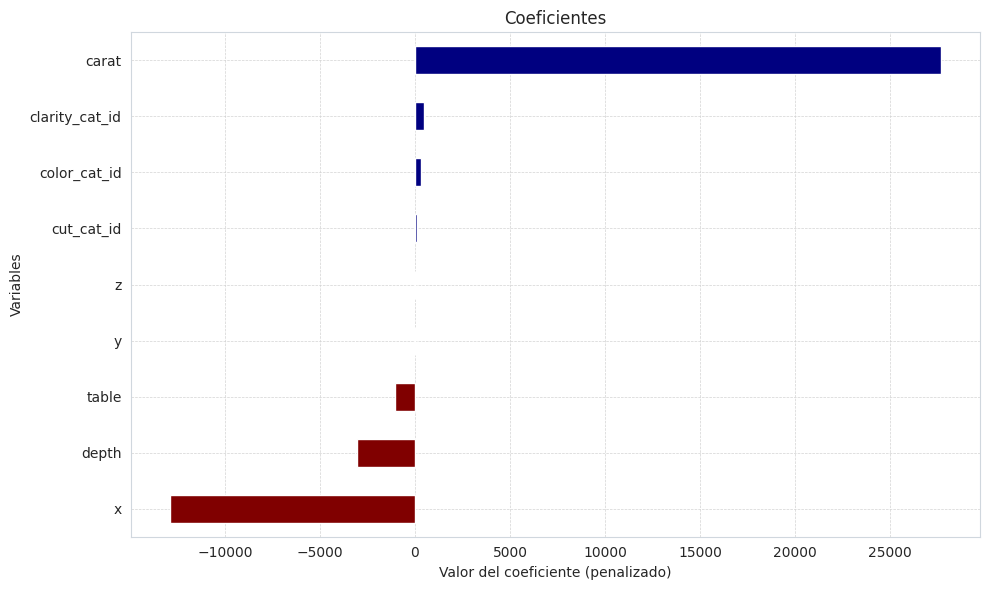

In [60]:
#Instanciamos el modelo
lasso_model = LassoRegression(X_train, X_test, y_train, y_test)

#Entrenamos y ajustamos
lasso_model.fit_reg(alpha = best_alpha)

#Coeficientes del modelo
lasso_model.coefs()

#Validación cruzada
lasso_model.cross_values()

#Performance 
lasso_model.performance()

#Coeficientes regularizados
lasso_model.plot_features()

### Elastic Net

In [61]:
class ElasticNetReg:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
        self.model = None
        self.y_fitted = None
        self.y_pred = None

    #Ajustamos el modelo
    def fit_reg(self, alpha = 1, l1_ratio = 0.5):
        self.model = ElasticNet(fit_intercept=True, alpha = alpha, l1_ratio = l1_ratio)
        self.model.fit(self.X_train, self.y_train)
        
        #Calculamos predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)
        return self.model

    #Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
            
        cfs = [self.model.intercept_]
        cfs.extend(list(self.model.coef_))
        coef_names = ["intercept"] + list(self.X_train.columns)

        dt = {"Vars": coef_names, "Coefs": cfs}
        return pd.DataFrame(dt)

    #Validacion cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")
        
        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="r2"
        )
        cv_values = {
            "media": np.round(np.mean(cv_score),3),
            "mediana": np.round(np.median(cv_score),3),
            "desv. est": np.round(np.std(cv_score, ddof=1),3)
        }
        return cv_values

    #Metricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_reg() para calcular predicciones")
        
        r2_train = np.round(r2_score(self.y_train, self.y_fitted), 3)
        r2_test  = np.round(r2_score(self.y_test, self.y_pred), 3)

        rmse_train = np.round(root_mean_squared_error(self.y_train, self.y_fitted), 3)
        rmse_test  = np.round(root_mean_squared_error(self.y_test, self.y_pred), 3)

        mae_train = np.round(mean_absolute_error(self.y_train, self.y_fitted), 3)
        mae_test  = np.round(mean_absolute_error(self.y_test, self.y_pred), 3)

        mape_train = np.round(mean_absolute_percentage_error(self.y_train, self.y_fitted), 3)
        mape_test  = np.round(mean_absolute_percentage_error(self.y_test, self.y_pred), 3)

        perform = {
            "Metrica": [
                "R2_train", "R2_test",
                "rmse_train", "rmse_test",
                "mae_train", "mae_test",
                "mape_train", "mape_test"
            ],
            "Valor": [
                r2_train, r2_test,
                rmse_train, rmse_test,
                mae_train, mae_test,
                mape_train, mape_test
            ]
        }
        return pd.DataFrame(perform)
    
    #Graficamos las variables penalizadas
    def plot_features(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_reg()")

        coefs = pd.Series(self.model.coef_, index=self.X_train.columns)
        coefs_sorted = coefs.sort_values()

        plt.figure(figsize=(10, 6))
        colors = ['#008080' if c < 0 else '#000067' for c in coefs_sorted]
        coefs_sorted.plot(kind='barh', color=colors)

        plt.title(f'Coeficientes')
        plt.xlabel('Valor del coeficiente (penalizado)')
        plt.ylabel('Variables')
        plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

**Búsqueda de hiperparámetros**

In [62]:
#Búsqueda de mejor hiperparametro alpha
elastic_cv = ElasticNet()

#Mejor parametro alpha
param_grid = {
    "alpha": uniform(0, 15),
    "l1_ratio" : uniform(0,1)
}

#Búsqueda aleatoria
elastic_search = RandomizedSearchCV(
    estimator=elastic_cv,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=1989,
    n_jobs=-1
)

elastic_search.fit(X_train, y_train)

#Mejores parámetros
best_elastic = elastic_search.best_estimator_
print("Mejor parámetro alpha:", elastic_search.best_params_)

best_alpha = elastic_search.best_params_["alpha"]
best_l1 = elastic_search.best_params_["l1_ratio"]

Mejor parámetro alpha: {'alpha': 0.36305048848093935, 'l1_ratio': 0.8691936961953901}


**Mejor modelo**

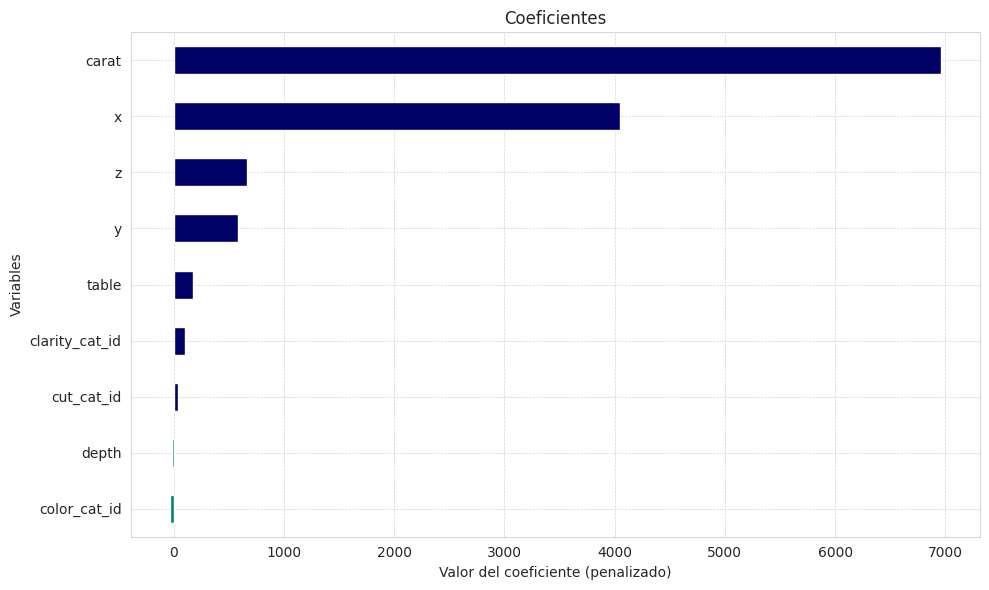

In [63]:
#Instanciamos el modelo
elastic_model = ElasticNetReg(X_train, X_test, y_train, y_test)

#Entrenamos y ajustamos
elastic_model.fit_reg(alpha = best_alpha, l1_ratio = best_l1)

#Coeficientes del modelo
elastic_model.coefs()

#Validación cruzada
elastic_model.cross_values()

#Performance 
elastic_model.performance()

#Coeficientes regularizados
elastic_model.plot_features()

## Comparación de Modelos

In [64]:
# performance = {}
performance = pd.DataFrame(index=['R2_train', 'R2_test', 'rmse_train', 'rmse_test', 'mae_train', 'mae_test', 'mape_train', 'mape_test'])
modelos = ['linear_regression', 'lasso', 'ridge', 'elastic']

for i, model in enumerate([lmodel, lasso_model, ridge_model, elastic_model]):
    # performance[i] = model.performance().set_index('Metrica')
    performance = performance.merge(
        model.performance().set_index('Metrica').rename(columns={'Valor': modelos[i]}), 
        left_index=True, 
        right_index=True, 
        how='left'
    )

In [65]:
performance

,linear_regression,lasso,ridge,elastic
R2_train,0.915,0.9150,0.915,0.672
R2_test,0.910,0.9097,0.910,0.667
rmse_train,1117.628,1117.7551,1117.645,2195.598
rmse_test,1145.262,1145.0196,1145.177,2199.875
mae_train,759.266,760.6755,759.875,1522.142
mae_test,764.182,765.5850,764.821,1516.487
mape_train,0.418,0.4198,0.419,0.774
mape_test,0.426,0.4275,0.427,0.781


## Practica 02 - Irani Churn

In [66]:
calls = pd.read_csv(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-II/Datasets/Customer_Churn.csv')

In [67]:
calls.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [68]:
calls.shape

(3150, 14)

## Descripción del Dataset

*Este conjunto de datos fue recolectado aleatoriamente de la base de datos de una compañía de telecomunicaciones iraní durante un periodo de 12 meses. Consta de un total de 3,150 registros, cada uno representando a un cliente, con información en 13 columnas.*

| Variable Name           | Role    | Type       | Description                                                       |
| ----------------------- | ------- | ---------- | ----------------------------------------------------------------- |
| Call Failure            | Feature | Integer    | Número de llamadas fallidas                                       |
| Complains               | Feature | Binary     | Quejas del cliente (0 = No, 1 = Sí)                               |
| Subscription Length     | Feature | Integer    | Meses totales de suscripción                                      |
| Charge Amount           | Feature | Integer    | Monto de cargos (0 = más bajo, 9 = más alto)                      |
| Seconds of Use          | Feature | Integer    | Total de segundos en llamadas                                     |
| Frequency of use        | Feature | Integer    | Número total de llamadas realizadas                               |
| Frequency of SMS        | Feature | Integer    | Número total de mensajes SMS enviados                             |
| Distinct Called Numbers | Feature | Integer    | Cantidad de números de teléfono distintos llamados                |
| Age Group               | Feature | Integer    | Grupo de edad (1 = más joven, 5 = mayor)                          |
| Tariff Plan             | Feature | Integer    | Plan de tarifa (1 = prepago, 2 = contrato)                        |
| Status                  | Feature | Binary     | Estado del cliente (1 = activo, 2 = inactivo)                     |
| Age                     | Feature | Integer    | Edad exacta del cliente                                           |
| Customer Value          | Feature | Continuous | Valor calculado del cliente                                       |
| Churn                   | Target  | Binary     | Variable objetivo: 1 = Churn (abandono), 0 = No Churn (retención) |




*Los atributos incluidos en este conjunto de datos son: fallas en llamadas, frecuencia de SMS, número de quejas, número de llamadas distintas, duración de la suscripción, grupo de edad, monto de cargos, tipo de servicio, segundos de uso, estado, frecuencia de uso y valor del cliente.*

*Todos los atributos, excepto la variable churn, corresponden a datos agregados de los primeros 9 meses. Las etiquetas de churn reflejan el estado de los clientes al finalizar los 12 meses. Los tres meses restantes representan el periodo definido como brecha de planeación. Data Set Recolectado de:
https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset*

## Valores Ausentes

In [69]:
is_na_df(calls)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,44100,0.0,1.0


## Estadísticos

In [70]:
var = {i: x for i, x in enumerate(calls.columns)}

In [71]:
var

{0: 'Call  Failure',
 1: 'Complains',
 2: 'Subscription  Length',
 3: 'Charge  Amount',
 4: 'Seconds of Use',
 5: 'Frequency of use',
 6: 'Frequency of SMS',
 7: 'Distinct Called Numbers',
 8: 'Age Group',
 9: 'Tariff Plan',
 10: 'Status',
 11: 'Age',
 12: 'Customer Value',
 13: 'Churn'}

In [72]:
cat_id_cols = [1,3,8,9,10,13]

cat_cols = [var[i] for i in range(var.__len__()) if i in cat_id_cols]
print('cat_cols =', cat_cols, end='\n'*2)

num_cols = [var[i] for i in range(var.__len__()) if i not in cat_id_cols]
print('num_cols =', num_cols)

cat_cols = ['Complains', 'Charge  Amount', 'Age Group', 'Tariff Plan', 'Status', 'Churn']

num_cols = ['Call  Failure', 'Subscription  Length', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age', 'Customer Value']


In [73]:
calls.describe(percentiles=percentiles).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Call Failure,3150.0,7.627937,7.263886,0.0,0.0,0.000,1.00000,6.00,12.00000,22.00,30.0000,36.00
Complains,3150.0,0.076508,0.265851,0.0,0.0,0.000,0.00000,0.00,0.00000,1.00,1.0000,1.00
Subscription Length,3150.0,32.541905,8.573482,3.0,7.0,13.000,30.00000,35.00,38.00000,42.00,45.0000,47.00
Charge Amount,3150.0,0.942857,1.521072,0.0,0.0,0.000,0.00000,0.00,1.00000,4.00,8.0000,10.00
Seconds of Use,3150.0,4472.459683,4197.908687,0.0,0.0,54.500,1391.25000,2990.00,6478.25000,15020.50,16127.6500,17090.00
Frequency of use,3150.0,69.460635,57.413308,0.0,0.0,1.000,27.00000,54.00,95.00000,184.55,238.5100,255.00
Frequency of SMS,3150.0,73.174921,112.237560,0.0,0.0,0.000,6.00000,21.00,87.00000,356.55,483.0000,522.00
Distinct Called Numbers,3150.0,23.509841,17.217337,0.0,0.0,1.000,10.00000,21.00,34.00000,51.00,80.0000,97.00
Age Group,3150.0,2.826032,0.892555,1.0,1.0,2.000,2.00000,3.00,3.00000,5.00,5.0000,5.00
Tariff Plan,3150.0,1.077778,0.267864,1.0,1.0,1.000,1.00000,1.00,1.00000,2.00,2.0000,2.00


In [74]:
analisis_calls = analyze(calls, num_cols, cat_cols)

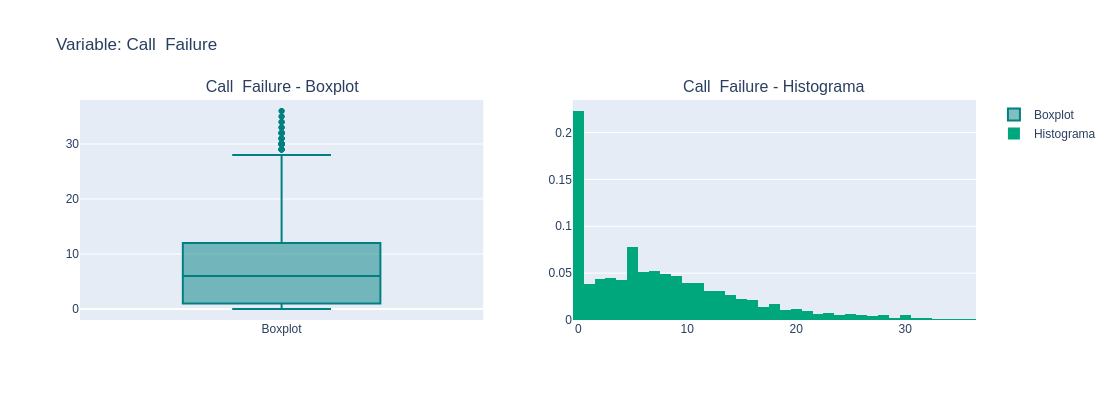

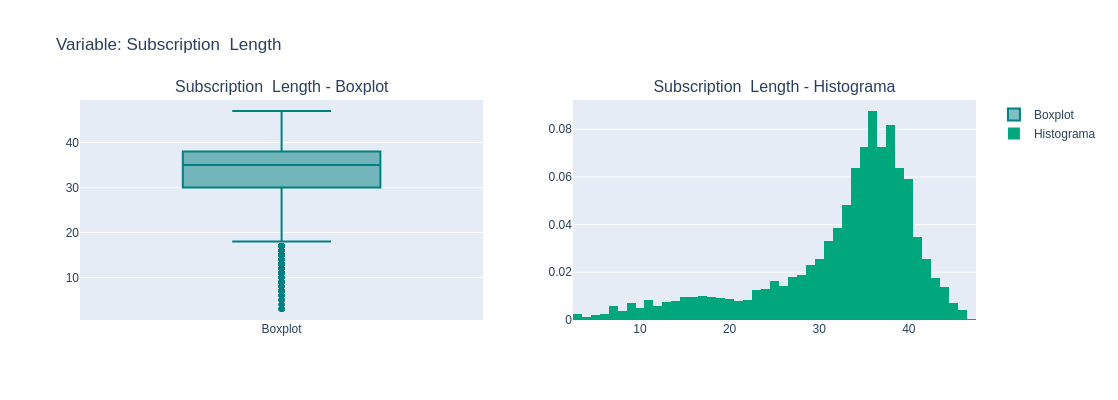

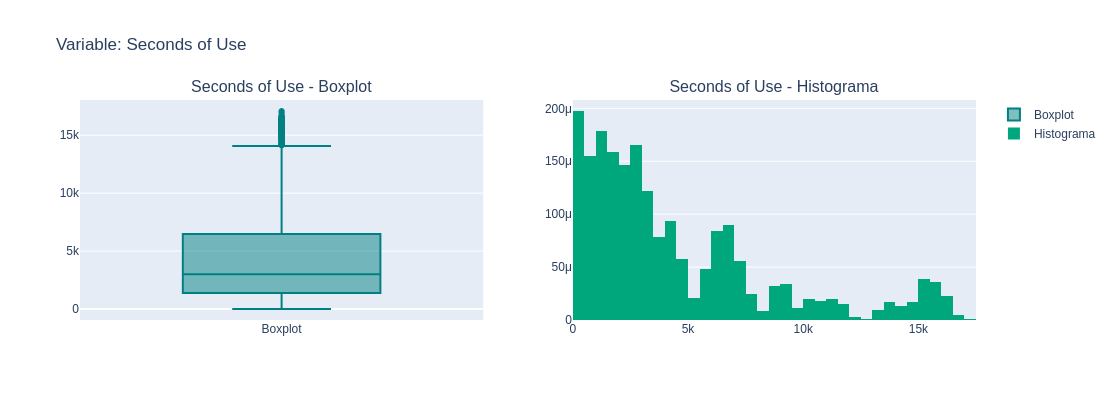

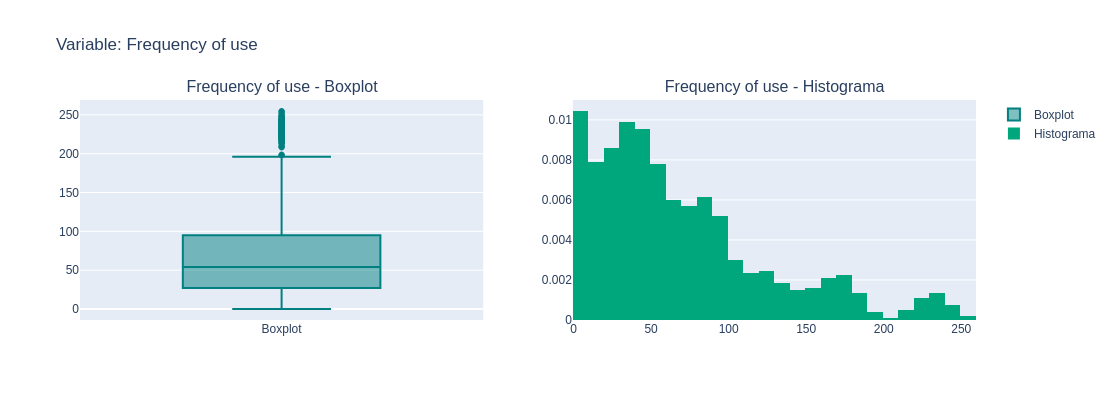

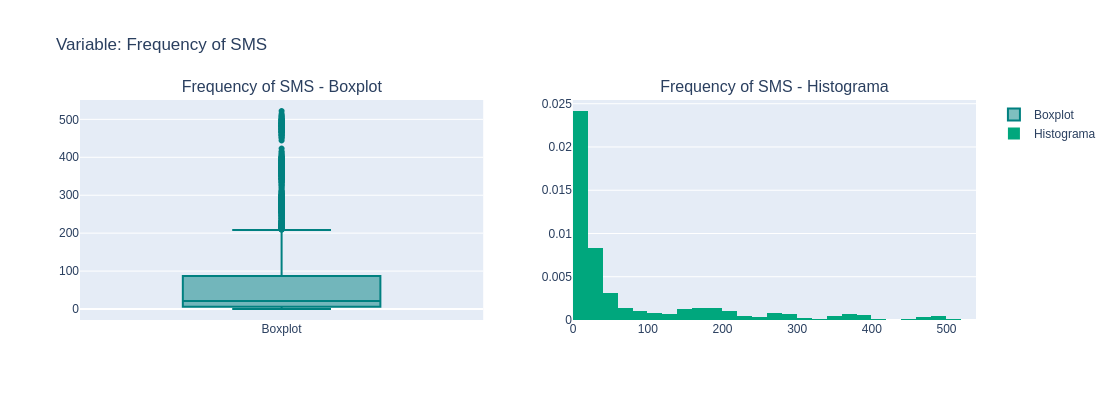

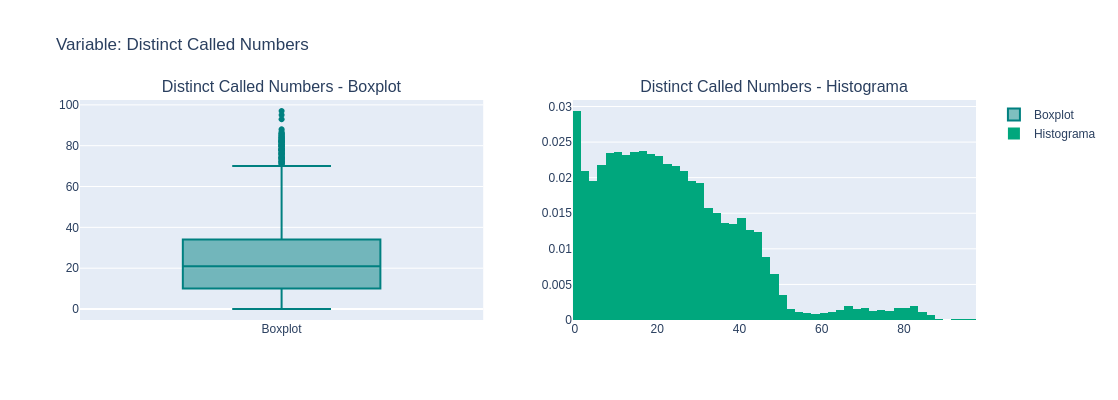

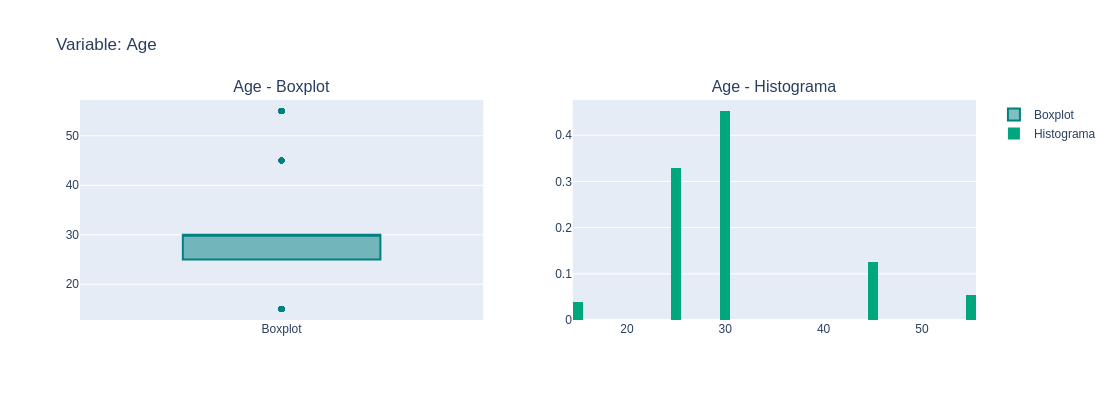

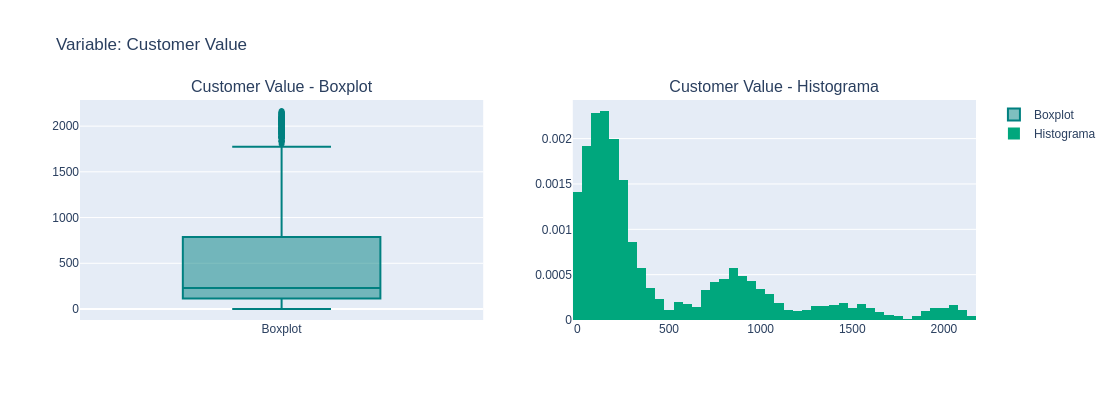

In [75]:
analisis_calls.plot_num()

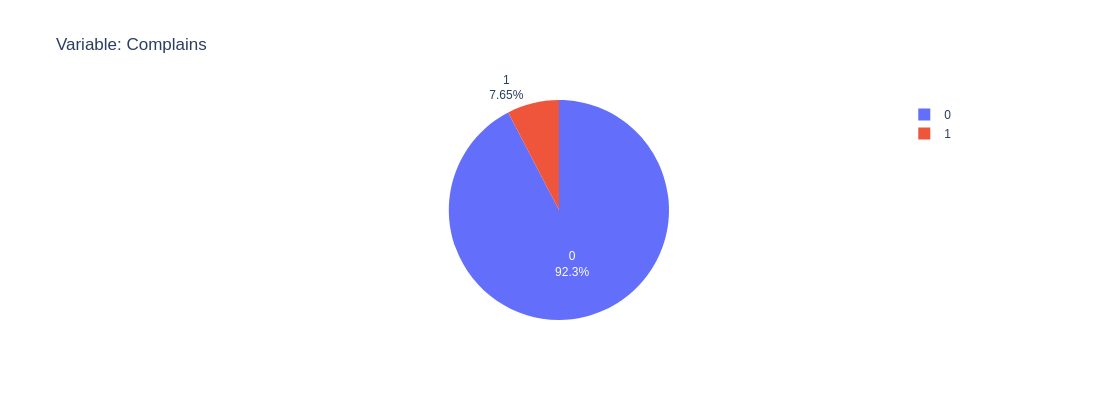

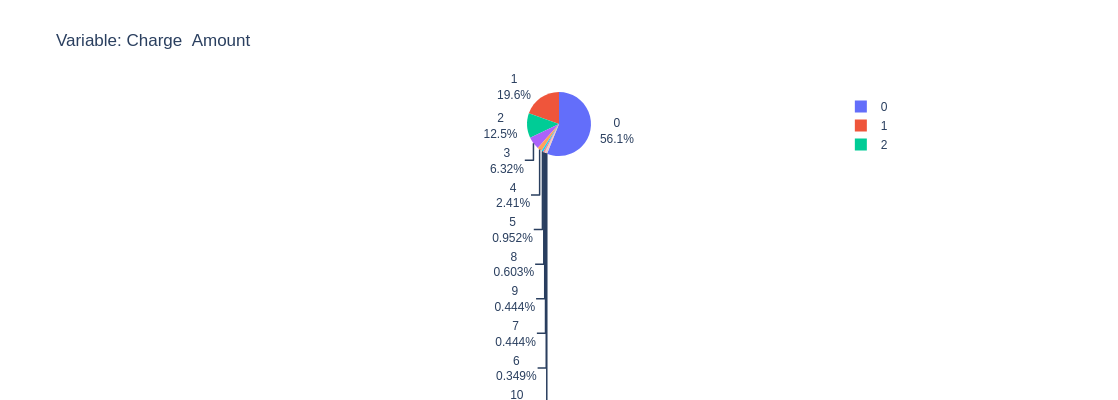

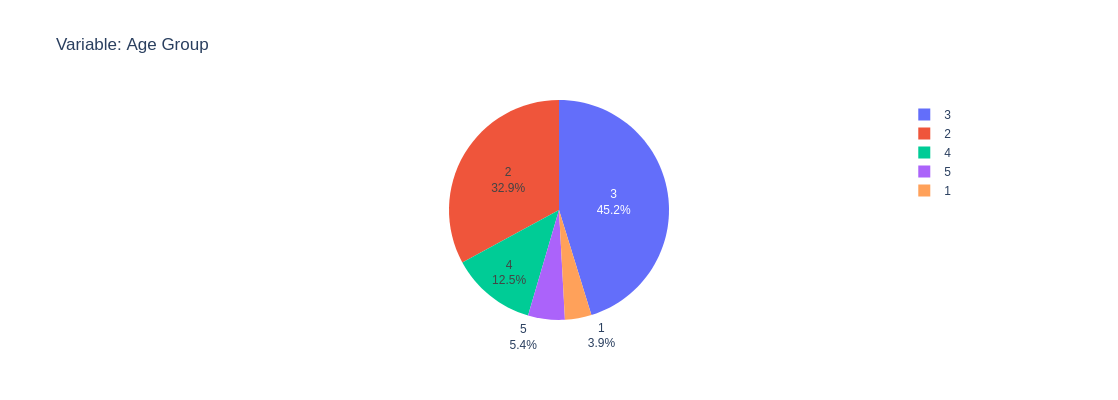

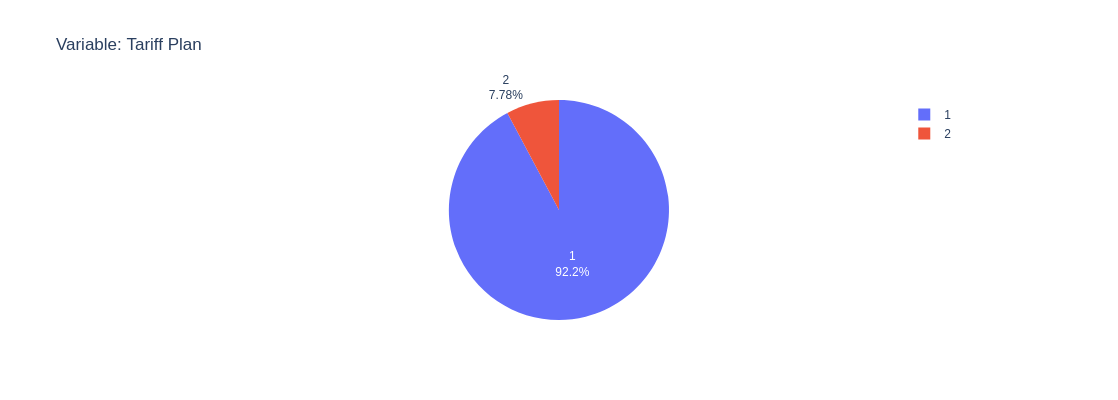

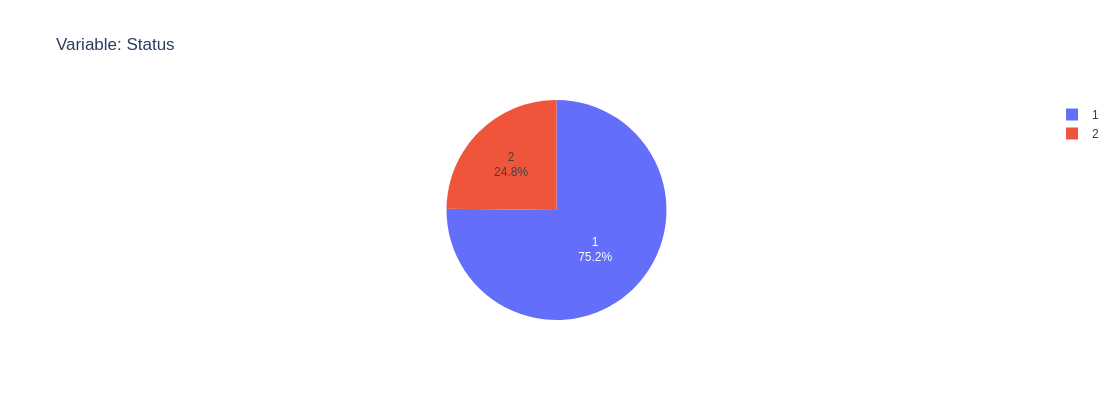

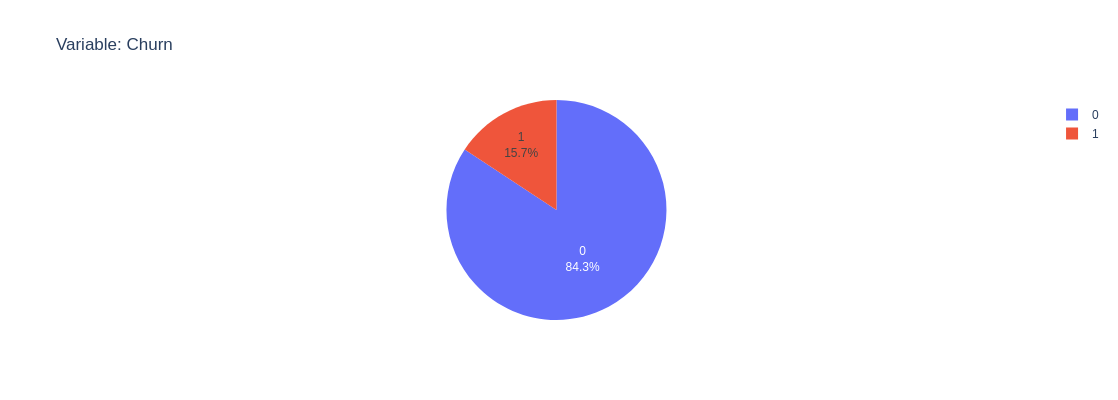

In [76]:
analisis_calls.plot_cat()

## Valores Atípicos

In [77]:
calls_clean = calls.copy()

In [78]:
calls_clean.drop(columns=['Complains', 'Tariff Plan'], inplace=True)

In [79]:
calls_clean.columns = ['_'.join([y.lower() for y in x.split()]) for x in calls_clean.columns]

In [80]:
calls_clean.head(3)

,call_failure,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,status,age,customer_value,churn
0,8,38,0,4370,71,5,17,3,1,30,197.640,0
1,0,39,0,318,5,7,4,2,2,25,46.035,0
2,10,37,0,2453,60,359,24,3,1,30,1536.520,0


**<h3>call failure</h3>**

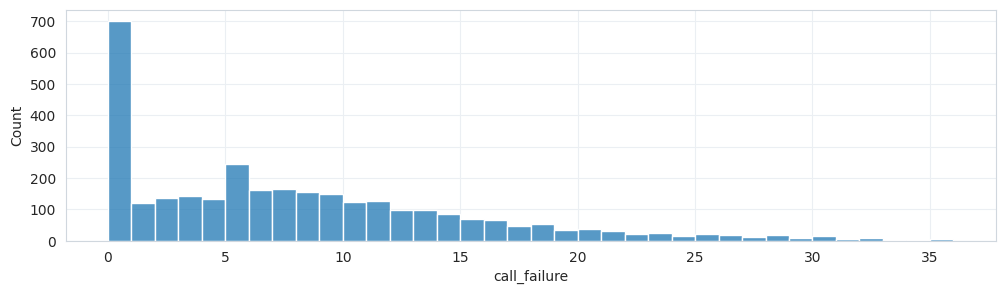

In [81]:
plt.figure(figsize=(12,3))
sns.histplot(calls_clean['call_failure'], bins=36)
plt.show()

In [82]:
calls_clean.loc[calls_clean['call_failure'] == 0].describe(percentiles=percentiles).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
call_failure,702.0,0.000000,0.000000,0.0,0.00,0.0,0.00000,0.0000,0.0000,0.00,0.00,0.00
subscription_length,702.0,29.991453,8.534728,3.0,3.01,8.0,27.00000,33.0000,36.0000,39.00,40.99,43.00
charge_amount,702.0,0.069801,0.281578,0.0,0.00,0.0,0.00000,0.0000,0.0000,1.00,1.00,2.00
seconds_of_use,702.0,2147.715100,2610.404034,0.0,0.00,0.0,250.50000,1281.5000,2920.0000,6794.35,13204.60,14920.00
frequency_of_use,702.0,31.740741,36.671593,0.0,0.00,0.0,3.25000,19.0000,47.7500,111.00,153.00,166.00
frequency_of_sms,702.0,57.435897,112.962573,0.0,0.00,0.0,0.00000,2.0000,29.0000,355.80,467.99,508.00
distinct_called_numbers,702.0,12.411681,13.686526,0.0,0.00,0.0,2.00000,8.0000,19.0000,40.00,64.99,70.00
age_group,702.0,2.764957,0.887557,1.0,1.00,2.0,2.00000,3.0000,3.0000,4.00,5.00,5.00
status,702.0,1.374644,0.484376,1.0,1.00,1.0,1.00000,1.0000,2.0000,2.00,2.00,2.00
age,702.0,30.833333,8.718739,15.0,15.00,25.0,25.00000,30.0000,30.0000,45.00,55.00,55.00


In [83]:
'{0:.2%}'.format(calls_clean['call_failure'].value_counts(normalize=True)[0])

'22.29%'

* La proporción de valores con 0 es bastante alta, si los ceros fueran valores ausentes podríamos sesgar al imputar valores donde sea 0.
* El 50% de clientes tienen categoría de activo y el resto de inactivo.

**<h3>customer value</h3>**

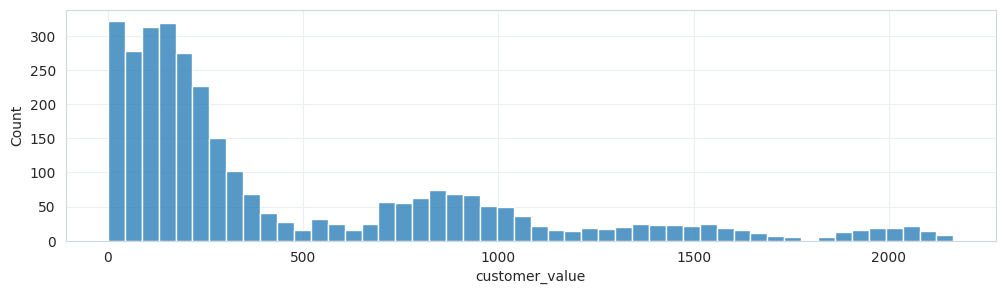

In [84]:
plt.figure(figsize=(12,3))
sns.histplot(calls_clean['customer_value'], bins=50)
plt.show()

In [85]:
calls_clean.loc[calls_clean['customer_value'] == 0].describe(percentiles=percentiles).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
call_failure,132.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
subscription_length,132.0,32.257576,5.400906,3.0,9.79,23.0,30.75,34.0,35.0,37.0,39.00,40.0
charge_amount,132.0,0.015152,0.122621,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.69,1.0
seconds_of_use,132.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
frequency_of_use,132.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
frequency_of_sms,132.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
distinct_called_numbers,132.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
age_group,132.0,2.818182,1.047120,2.0,2.00,2.0,2.00,2.0,4.0,5.0,5.00,5.0
status,132.0,1.765152,0.425519,1.0,1.00,1.0,2.00,2.0,2.0,2.0,2.00,2.0
age,132.0,32.310606,10.491823,25.0,25.00,25.0,25.00,25.0,45.0,55.0,55.00,55.0


In [86]:
'{0:.2%}'.format(calls_clean['customer_value'].value_counts(normalize=True)[0])

'4.19%'

* La proporción de valores con 0 es baja (4.2%), si los ceros fueran valores ausentes podríamos imputar valores donde sea 0. Sin embargo, vemos en el descriptivo que el 75% de los clientes son inactivos y al 25% que aparece como activo no tiene frecuencia de uso mayor a 0, lo que si podemos hacer en este paso es pasar el 25% que aparece como activo a inactivo en **status** para marcarlos como el resto de clientes.
* Un 1% de estos clientes tiene un monto de cargo lo cual hace poco sentido ya que el resto (99%) no tiene ningún cargo.

**<h3>distinct called numbers</h3>**

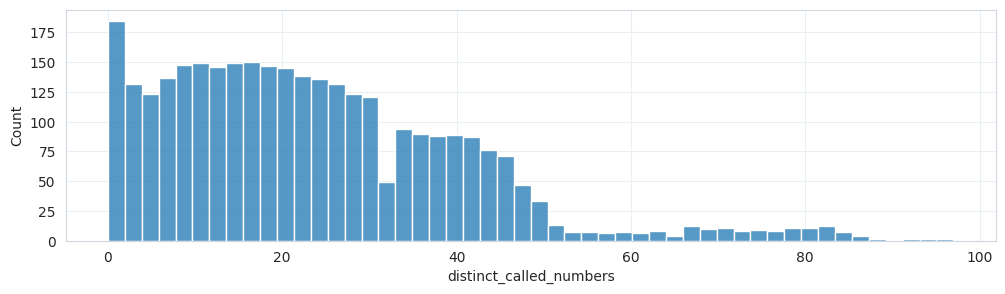

In [87]:
plt.figure(figsize=(12,3))
sns.histplot(calls_clean['distinct_called_numbers'], bins=50)
plt.show()

In [88]:
calls_clean.loc[calls_clean['distinct_called_numbers'] == 0].describe(percentiles=percentiles).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
call_failure,154.0,0.000000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0,0.000,0.000,0.0
subscription_length,154.0,32.285714,5.776575,3.0,11.77,21.65,30.0,34.0,36.0,38.350,40.470,42.0
charge_amount,154.0,0.019481,0.138657,0.0,0.00,0.00,0.0,0.0,0.0,0.000,1.000,1.0
seconds_of_use,154.0,0.000000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0,0.000,0.000,0.0
frequency_of_use,154.0,0.000000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0,0.000,0.000,0.0
frequency_of_sms,154.0,0.993506,3.453703,0.0,0.00,0.00,0.0,0.0,0.0,7.350,17.580,25.0
distinct_called_numbers,154.0,0.000000,0.000000,0.0,0.00,0.00,0.0,0.0,0.0,0.000,0.000,0.0
age_group,154.0,2.857143,1.050543,2.0,2.00,2.00,2.0,2.0,4.0,5.000,5.000,5.0
status,154.0,1.785714,0.411665,1.0,1.00,1.00,2.0,2.0,2.0,2.000,2.000,2.0
age,154.0,32.694805,10.558476,25.0,25.00,25.00,25.0,25.0,45.0,55.000,55.000,55.0


In [89]:
'{0:.2%}'.format(calls_clean['distinct_called_numbers'].value_counts(normalize=True)[0])

'4.89%'

* La proporción de valores con 0 es baja (4.9%), si los ceros fueran valores ausentes podríamos imputar valores donde sea 0. Sin embargo, vemos en el descriptivo que el 75% de los clientes son inactivos y al 25% que aparece como activo no tiene frecuencia de uso mayor a 0, lo que si podemos hacer en este paso es pasar el 25% que aparece como activo a inactivo en **status** para marcarlos como el resto de clientes.
* Un 1% de estos clientes tiene un monto de cargo lo cual haace poco sentido ya que el resto (99%) no tiene ningún cargo.

In [90]:
calls_clean.loc[(calls_clean['customer_value'] == 0) & (calls_clean['distinct_called_numbers'] == 0) \
    & (calls_clean['call_failure'] == 0)].shape

(132, 12)

Si bien hemos observado algunos valores en 0 que podrían parecer valores ausentes, por la naturaleza de los datos concluimos que deberíamos dejarlos en el dataset ya que como se puede ver en la celda anterior. Encontramos esos 3 campos en 0, igual a la dimensión de **customer_value** = 0. Esto quiere decir, que si hubiera sido menor la dimensión entonces cada variable hubiera tenido un comportamiento independiente de la otra, sin embargo al obtener la misma dimensión, podemos concluir que los valores están relacionados y que se pueden explicar con alguna de las otras variables.

## Codificación de Variables

In [91]:
calls_clean.loc[:, 'charge_amount_recat'] = pd.Categorical(
    pd.cut(calls_clean["charge_amount"], bins=[0,3,5,10], labels=['bajo', 'medio', 'alto'], include_lowest=True),
    categories=['bajo', 'medio', 'alto'],
    ordered=True
)

In [92]:
calls_clean.loc[:, 'charge_amount_recat_id'] = np.ravel(OrdinalEncoder(categories=[['bajo', 'medio', 'alto']]).fit_transform(calls_clean.loc[:, ['charge_amount_recat']]))

**age_group** ya no es necesario codificarla porque ya existe una variable con la codificación de la edad.

In [93]:
calls_clean.loc[:, ['age','age_group']].drop_duplicates().sort_values(by='age')

,age,age_group
3,15,1
1,25,2
0,30,3
20,45,4
23,55,5


**status** tampoco vamos a codificarla ya que es binaria (1: cliente activo y 2: cliente inactivo)

In [94]:
calls_clean.drop(columns=['charge_amount_recat', 'charge_amount', 'age'], inplace=True)
calls_clean.rename(columns={'charge_amount_recat_id': 'charge_amount'}, inplace=True)

In [95]:
cat_cols = ['charge_amount', 'age_group', 'status']

In [96]:
num_cols = [x for x in calls_clean.columns if x not in cat_cols+['churn']]

In [97]:
X = calls_clean.loc[:, cat_cols + num_cols]

In [98]:
y = calls_clean.loc[:, 'churn']

In [99]:
# Particion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y) # 1077

X_train_original = X_train.loc[:, num_cols].copy() # variables continuas en escala origen
X_test_original = X_test.copy()

# Escalamiento de variables continuas
scaler = MinMaxScaler()
scaler.fit(X_train.loc[:, num_cols])

X_train.loc[:, num_cols] = scaler.transform(X_train.loc[:, num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test.loc[:, num_cols])

In [101]:
class LogisticModel:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

        self.model = None
        self.y_pred_train = None
        self.y_pred_test = None
        self.proba_train = None
        self.proba_test = None

    # Ajuste del modelo
    def fit_model(self, **kwargs):
        self.model = LogisticRegression(**kwargs)
        self.model.fit(self.X_train, self.y_train)

        # Guardamos predicciones y probabilidades
        self.proba_train = self.model.predict_proba(self.X_train)[:,1]
        self.proba_test  = self.model.predict_proba(self.X_test)[:,1]

        self.y_pred_train = self.model.predict(self.X_train)
        self.y_pred_test  = self.model.predict(self.X_test)
        return self.model

    # Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")
        coef_names = ["intercept"] + list(self.X_train.columns)
        coefs = [self.model.intercept_[0]] + list(self.model.coef_[0])
        return pd.DataFrame({"Vars": coef_names, "Coef": coefs}).set_index("Vars")

    # Métricas de desempeño
    def performance(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")

        def calc_metrics(y_true, y_pred, proba):
            acc = accuracy_score(y_true, y_pred)
            sens = recall_score(y_true, y_pred)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            spec = tn / (tn + fp)
            auc = roc_auc_score(y_true, proba)
            return acc, sens, spec, auc

        metrics_train = calc_metrics(self.y_train, self.y_pred_train, self.proba_train)
        metrics_test  = calc_metrics(self.y_test, self.y_pred_test, self.proba_test)

        df_perf = pd.DataFrame({
            "Metrica": ["Accuracy", "Sensibilidad", "Especificidad", "AUC"],
            "Train": metrics_train,
            "Test": metrics_test
        })
        return df_perf

    # Curva ROC
    def plot_roc(self):
        if self.proba_test is None:
            raise ValueError("Primero ajusta el modelo con fit_model() para calcular probabilidades")

        fpr, tpr, thresholds = roc_curve(self.y_test, self.proba_test)
        auc_score = roc_auc_score(self.y_test, self.proba_test)

        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.3f})')
        plt.plot([0,1], [0,1], color='gray', linestyle='--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curva ROC")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    # Cross-validation con AUC
    """def cross_auc(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")

        auc_scorer = make_scorer(roc_auc_score, needs_proba=True)
        scores = cross_val_score(self.model, self.X_train, self.y_train,
                                 cv=cv, scoring=auc_scorer, n_jobs=-1)

        stats = {
            "media": np.round(np.mean(scores),4),
            "mediana": np.round(np.median(scores),4),
            "desv_est": np.round(np.std(scores, ddof=1),4)
        }
        return stats"""
    
    def cross_auc(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")
    
        cv_split = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
        scores = cross_val_score(
            self.model, self.X_train, self.y_train,
            cv=cv_split, scoring='roc_auc', n_jobs=-1
        )
    
        return {
            "media":  np.round(np.mean(scores), 4),
            "mediana": np.round(np.median(scores), 4),
            "desv_est": np.round(np.std(scores, ddof=1), 4),
        }

In [102]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer


In [103]:
#Instanciamos
reglog = LogisticModel(X_train, X_test, y_train, y_test)

In [104]:
reglog.fit_model(max_iter = 1000)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [105]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(2205, 10) (2205,) (945, 10) (945,)


In [106]:
#Coeficientes
reglog.coefs()

,Coef
Vars,
intercept,-2.493964
charge_amount,-1.118440
age_group,-0.036404
status,1.768584
call_failure,3.180449
subscription_length,-1.506128
seconds_of_use,-0.776242
frequency_of_use,-2.855207
frequency_of_sms,-1.948068


In [107]:
#Cross Validation
reglog.cross_auc()

{'media': 0.8819, 'mediana': 0.8804, 'desv_est': 0.0071}

In [108]:
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

In [109]:
auc_scorer

make_scorer(roc_auc_score, response_method='predict', needs_proba=True)

In [110]:
#Rendimiento
reglog.performance()

,Metrica,Train,Test
0,Accuracy,0.839909,0.848677
1,Sensibilidad,0.199422,0.167785
2,Especificidad,0.959118,0.976131
3,AUC,0.882872,0.892428


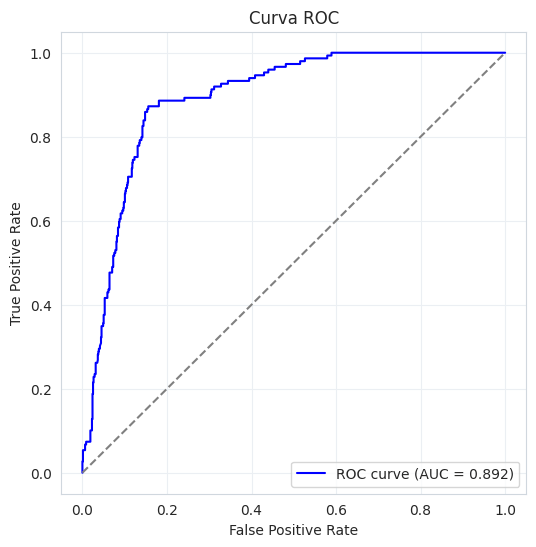

In [111]:
#Curva AUC
reglog.plot_roc()

In [112]:
pd.DataFrame(confusion_matrix(y_test, reglog.y_pred_test))

,0,1
0,777,19
1,124,25


In [113]:
from sklearn.metrics import classification_report
print(classification_report(y_test, reglog.y_pred_test))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92       796
           1       0.57      0.17      0.26       149

    accuracy                           0.85       945
   macro avg       0.72      0.57      0.59       945
weighted avg       0.82      0.85      0.81       945



In [114]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from scipy.stats import uniform

In [115]:
class RidgeClassifierModel:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

        self.model = None
        self.y_fitted = None
        self.y_pred = None

    # 🔹 Ajuste del modelo
    def fit_class(self, alpha=1):
        self.model = RidgeClassifier(alpha=alpha)
        self.model.fit(self.X_train, self.y_train)

        # Predicciones
        self.y_fitted = self.model.predict(self.X_train)
        self.y_pred = self.model.predict(self.X_test)

        return self.model

    # 🔹 Búsqueda de mejor hiperparámetro alpha
    def tune_alpha(self, n_iter=30, cv=5, scoring="accuracy", random_state=1989, alpha_max=15):
        print("Buscando mejor parámetro alpha...\n")
        ridge_search = RandomizedSearchCV(
            estimator=RidgeClassifier(),
            param_distributions={"alpha": uniform(0, alpha_max)},
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            random_state=random_state,
            n_jobs=-1
        )
        ridge_search.fit(self.X_train, self.y_train)

        best_alpha = ridge_search.best_params_["alpha"]
        print(f"✅ Mejor alpha encontrado: {best_alpha:.3f}")
        print(f"🏆 Mejor puntaje CV promedio ({scoring}): {ridge_search.best_score_:.3f}")

        # Ajustamos el modelo con el mejor alpha
        self.fit_class(alpha=best_alpha)
        return best_alpha, ridge_search

    # 🔹 Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_class()")

        cfs = [self.model.intercept_[0]]
        cfs.extend(list(self.model.coef_[0]))
        coef_names = ["intercept"] + list(self.X_train.columns)

        return pd.DataFrame({"Vars": coef_names, "Coefs": cfs})

    # 🔹 Validación cruzada
    def cross_values(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_class()")

        cv_score = cross_val_score(
            estimator=self.model,
            X=self.X_train,
            y=self.y_train,
            cv=cv,
            n_jobs=-1,
            scoring="accuracy"
        )
        return {
            "media": np.round(np.mean(cv_score), 3),
            "mediana": np.round(np.median(cv_score), 3),
            "desv. est": np.round(np.std(cv_score, ddof=1), 3)
        }

    # 🔹 Métricas de desempeño
    def performance(self):
        if self.y_fitted is None or self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_class()")
    
        # --- Métricas base ---
        acc_train = accuracy_score(self.y_train, self.y_fitted)
        acc_test  = accuracy_score(self.y_test, self.y_pred)
    
        # Sensibilidad (Recall positivo)
        sens_train = recall_score(self.y_train, self.y_fitted)
        sens_test  = recall_score(self.y_test, self.y_pred)
    
        # Especificidad (Recall negativo)
        cm_train = confusion_matrix(self.y_train, self.y_fitted)
        cm_test  = confusion_matrix(self.y_test, self.y_pred)
    
        # Evitar errores si falta alguna clase en los datos
        if cm_train.shape == (2,2):
            espec_train = cm_train[0,0] / (cm_train[0,0] + cm_train[0,1])
        else:
            espec_train = np.nan
    
        if cm_test.shape == (2,2):
            espec_test = cm_test[0,0] / (cm_test[0,0] + cm_test[0,1])
        else:
            espec_test = np.nan
    
        # AUC (usando decision_function para valores continuos)
        try:
            auc_train = roc_auc_score(self.y_train, self.model.decision_function(self.X_train))
            auc_test  = roc_auc_score(self.y_test,  self.model.decision_function(self.X_test))
        except Exception:
            auc_train, auc_test = np.nan, np.nan
    
        # --- Tabla resumen ---
        data = {
            "Métrica": ["Accuracy", "Sensibilidad", "Especificidad", "AUC"],
            "Train":   [acc_train, sens_train, espec_train, auc_train],
            "Test":    [acc_test,  sens_test,  espec_test,  auc_test]
        }
    
        df_metrics = pd.DataFrame(data)
        return df_metrics.round(6)

    # 🔹 Matriz de confusión
    def plot_confusion(self):
        if self.y_pred is None:
            raise ValueError("Primero ajusta el modelo con fit_class()")

        cm = confusion_matrix(self.y_test, self.y_pred)
        plt.figure(figsize=(5, 4))
        plt.imshow(cm, cmap="Blues", interpolation="nearest")
        plt.title("Matriz de confusión")
        plt.colorbar()
        plt.xticks([0, 1], ["Pred 0", "Pred 1"])
        plt.yticks([0, 1], ["Real 0", "Real 1"])

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.tight_layout()
        plt.show()

    # 🔹 Gráfico de coeficientes
    def plot_features(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_class()")

        coefs = pd.Series(self.model.coef_[0], index=self.X_train.columns)
        coefs_sorted = coefs.sort_values()

        plt.figure(figsize=(10, 6))
        colors = ['#de3163' if c < 0 else 'navy' for c in coefs_sorted]
        coefs_sorted.plot(kind='barh', color=colors)
        plt.title('Coeficientes penalizados (RidgeClassifier)')
        plt.xlabel('Valor del coeficiente')
        plt.ylabel('Variables')
        plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

**Mejor modelo**

Buscando mejor parámetro alpha...

✅ Mejor alpha encontrado: 0.177
🏆 Mejor puntaje CV promedio (f1): 0.269



,Métrica,Train,Test
0,Accuracy,0.850340,0.850794
1,Sensibilidad,0.187861,0.161074
2,Especificidad,0.973642,0.979899
3,AUC,0.882968,0.893574


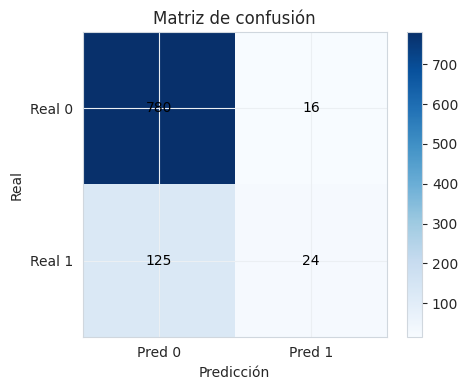

In [116]:
modelo = RidgeClassifierModel(X_train, X_test, y_train, y_test)

best_alpha, search_results = modelo.tune_alpha(
    n_iter=30,      # número de muestras aleatorias de alpha
    cv=5,           # número de folds en cross-validation
    scoring="f1",  # métrica para evaluar
    alpha_max=15    # rango máximo para alpha
)

print()
display(modelo.performance())

# Ver coeficientes penalizados
#modelo.coefs()

# Matriz de confusión
modelo.plot_confusion()

# Importancia de variables
#modelo.plot_features()